In [2]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt


# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [3]:
#Bringing in the data
data = pd.read_csv('Gross sales over time - 2024-06-20 - 2025-09-19.csv')
print(data.shape)

data.info()
data.describe()
data.head()


(457, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Day             457 non-null    object 
 1   Gross sales     457 non-null    float64
 2   Net sales       457 non-null    float64
 3   Net items sold  457 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 14.4+ KB


,Day,Gross sales,Net sales,Net items sold
0,2024-06-20,4483.86,4110.22,4
1,2024-06-21,0.00,0.00,0
2,2024-06-22,0.00,0.00,0
3,2024-06-23,0.00,0.00,0
4,2024-06-24,0.00,0.00,0


In [4]:
#Visualizing the data

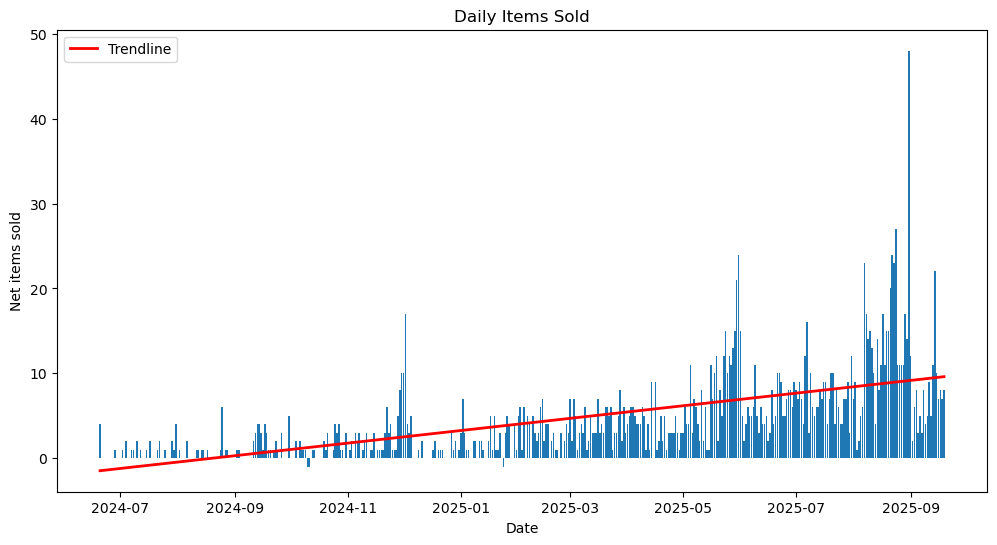

In [5]:
# Items sold over time
plt.figure(figsize=(12,6))

#Changin "Day" as date time
data["Day"]=pd.to_datetime(data["Day"])

# Bar chart
plt.bar(data["Day"], data["Net items sold"])
plt.xlabel("Date")
plt.ylabel("Net items sold")
plt.title("Daily Items Sold")

# Fitting a linear trendline for illustration
x = np.arange(len(data))
y = data["Net items sold"].values
coeffs = np.polyfit(x, y, 1)
trendline = np.poly1d(coeffs)

# Plotting the trendline
plt.plot(data["Day"], trendline(x), color="red", linewidth=2, label="Trendline")
plt.legend()

# Show figure
plt.show()

In [6]:
#Feature engineering for ML model

In [7]:
# Adding columns
data["Avg_Price_per_unit"] = np.where(
    data["Net items sold"]==0,
    0,
    data["Gross sales"] / data["Net items sold"])                       # Price per product
data["Sales_lag1"] = data["Net items sold"].shift(1)                    # Previous day's sales
data["Sales_lag7"] = data["Net items sold"].shift(7)                    # Previous week's sales
data["Month"] = data["Day"].dt.month
data["Day_of_week"] = data["Day"].dt.dayofweek

# Changing categorical features into dummies
data = pd.get_dummies(data, columns=["Month"], prefix="month", dtype=int)
data = pd.get_dummies(data, columns=["Day_of_week"], prefix="dow", dtype=int)

# Rolling average
data["Rolling7"] = data["Net items sold"].rolling(window=7).mean()

# Dropping NaN rows and rows with infinity values
data = data.dropna().reset_index(drop=True)


# Reordering for clarity
data = data[
    ["Net items sold", "Avg_Price_per_unit", "Sales_lag1", "Sales_lag7", "Rolling7"]
    + [col for col in data.columns if col.startswith("dow_")]
    + [col for col in data.columns if col.startswith("month_")]
]

# Quick check
data.tail()

,Net items sold,Avg_Price_per_unit,Sales_lag1,Sales_lag7,Rolling7,dow_0,dow_1,dow_2,dow_3,dow_4,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
445,10,1579.088000,22.0,8.0,9.428571,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
446,7,1492.445714,10.0,4.0,9.857143,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
447,8,1188.426250,7.0,5.0,10.285714,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
448,7,1365.851429,8.0,9.0,10.000000,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
449,8,1215.062500,7.0,5.0,10.428571,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [8]:
# Splitting the data into training, testing and validation

y = data["Net items sold"]

X = data[data.columns]
X = X.drop(columns = ["Net items sold"])

X

,Avg_Price_per_unit,Sales_lag1,Sales_lag7,Rolling7,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0.000000,0.0,4.0,0.000000,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1443.550000,0.0,0.0,0.142857,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,0.000000,1.0,0.0,0.142857,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0.000000,0.0,0.0,0.142857,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.000000,0.0,0.0,0.142857,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1579.088000,22.0,8.0,9.428571,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
446,1492.445714,10.0,4.0,9.857143,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
447,1188.426250,7.0,5.0,10.285714,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
448,1365.851429,8.0,9.0,10.000000,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [9]:
# Creating training, validation and test data
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:], y.iloc[val_end:]

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 315
Validation size: 67
Test size: 68


In [10]:
# //Fitting linear regression with training data

regr = LinearRegression()
regr.fit(X_train,y_train)


# Testing model with validation data
y_val_pred = regr.predict(X_val)
tr_error_validation = mean_squared_error(y_val, y_val_pred)
print(f"Training error validation set: {tr_error_validation}")

# Training model with training + validation data

X_trval = X.iloc[:val_end]
y_trval = y.iloc[:val_end]
regr.fit(X_trval, y_trval)

# Testing model with testing data

y_test_pred = regr.predict(X_test)
tr_error_test = mean_squared_error(y_test, y_test_pred)

print('The training error for test set is: ', tr_error_test)    # print the training error





Training error validation set: 13.196183657748133
The training error for test set is:  42.03429329425465


In [11]:
# //Fitting linear regression for the whole set as a reference

regr2 = LinearRegression()
regr2.fit(X,y)

#Testing model

y_pred2 = regr2.predict(X)
tr_error2 = mean_squared_error(y, y_pred2)
print(f"The training error for the whole set is: {tr_error2}")

The training error for the whole set is: 9.299259801075896


In [12]:
# //Fitting Decision Tree Regression

max_depth = [2,5,10]
min_samples_leaf = [2,5,10]

for i in max_depth:
    for j in min_samples_leaf:
        
        print(f"max_depth = {i} and min_samples_leaf = {j}")
        tree = DecisionTreeRegressor(max_depth=i,random_state=42, min_samples_leaf=j)
        tree.fit(X_train,y_train)

        # Evaluating on Validation data
        y_tree_predict_val = tree.predict(X_val)
        tr_error_tree_val = mean_squared_error(y_val,y_tree_predict_val)
        print(f"Training error on validation data: {tr_error_tree_val}")
        
        #Training on Training+Validation
        tree.fit(X_trval, y_trval)

        #Evaluating on Test data
        y_tree_predict = tree.predict(X_test)
        tr_error_tree  = mean_squared_error(y_test,y_tree_predict)
        
        #Printing the results
        print(f'The training error for test set is: ', tr_error_tree)    # print the training error
        print("----------------------------------------------------------------------------------")



max_depth = 2 and min_samples_leaf = 2
Training error on validation data: 27.39695907038879
The training error for test set is:  44.581608643457386
----------------------------------------------------------------------------------
max_depth = 2 and min_samples_leaf = 5
Training error on validation data: 27.39695907038879
The training error for test set is:  44.581608643457386
----------------------------------------------------------------------------------
max_depth = 2 and min_samples_leaf = 10
Training error on validation data: 27.39695907038879
The training error for test set is:  44.581608643457386
----------------------------------------------------------------------------------
max_depth = 5 and min_samples_leaf = 2
Training error on validation data: 15.766364857384364
The training error for test set is:  62.20579661905914
----------------------------------------------------------------------------------
max_depth = 5 and min_samples_leaf = 5
Training error on validation data: 1

In [ ]:
#As we can see, the limited training data makes the results unreliable; however, I hope the project demonstrates the types of topics I have been working on.